# **AGRICULTURE**

---



# Initialisation environnement

Cette section permet de configurer l’environnement d’exécution et d’importer la base de données nécessaire aux analyses.

In [3]:
import mysql.connector

In [5]:
!service mysql start

 * Starting MySQL database server mysqld
   ...done.


In [6]:
!mysql -u root -e "CREATE DATABASE agriculture;"

In [7]:

# INSTALLATION + LANCEMENT MYSQL

!pip install mysql-connector-python > /dev/null
!apt-get update -y > /dev/null
!DEBIAN_FRONTEND=noninteractive apt-get install -y mysql-server > /dev/null

!service mysql start

# UPLOAD DU FICHIER SQL

from google.colab import files
uploaded = files.upload()

sql_file = list(uploaded.keys())[0]
print("Fichier uploadé :", sql_file)

# CONFIGURATION MYSQL

!mysql -u root -e "ALTER USER 'root'@'localhost' IDENTIFIED WITH mysql_native_password BY ''; FLUSH PRIVILEGES;"


# Importer dans la bonne base
!mysql -u root agriculture < "{sql_file}"

# Vérifier tables
!mysql -u root -e "USE agriculture; SHOW TABLES;"

# CONNEXION PYTHON


bdd = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",
    database="agriculture"
)

print("Connexion SQL OK ✅")



W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
 * Starting MySQL database server mysqld
   ...done.


Saving agriculture(1).sql to agriculture(1) (2).sql
Fichier uploadé : agriculture(1) (2).sql
+------------------------+
| Tables_in_agriculture  |
+------------------------+
| adapter                |
| contrainte_temperature |
| culture                |
| releve_meteo           |
| saisonnalite           |
| station_meteo          |
| type_sol               |
| villes                 |
+------------------------+
Connexion SQL OK ✅


In [8]:
import mysql.connector
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from matplotlib.lines import Line2D


# Analyse exploratoire climatique

Hypothèse : Les conditions climatiques évoluent selon les années et les interactions entre variables météorologiques influencent les décisions agricoles.

/tmp/ipykernel_643/4260887647.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  releve = pd.read_sql("SELECT * FROM releve_meteo", bdd)


<Figure size 1000x600 with 0 Axes>

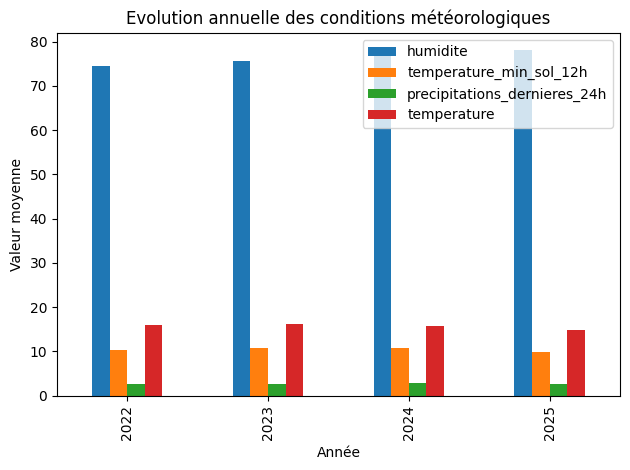

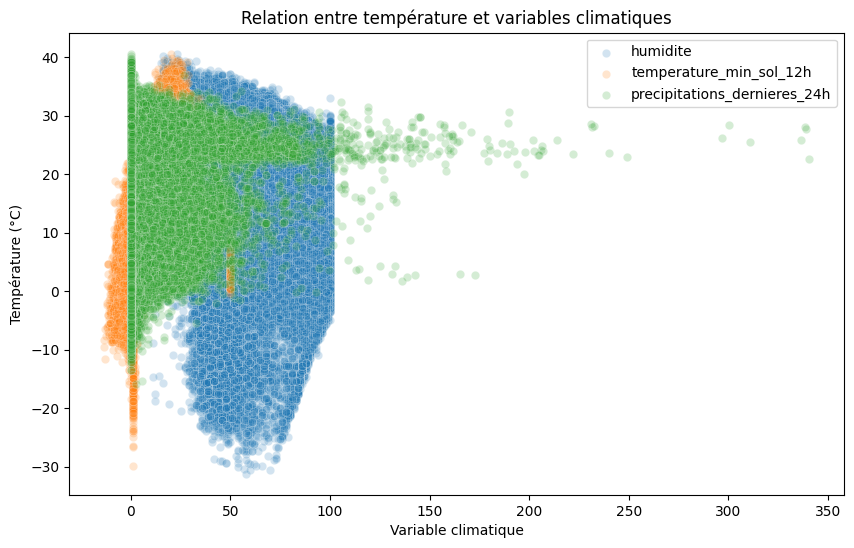

NameError: name 'année' is not defined

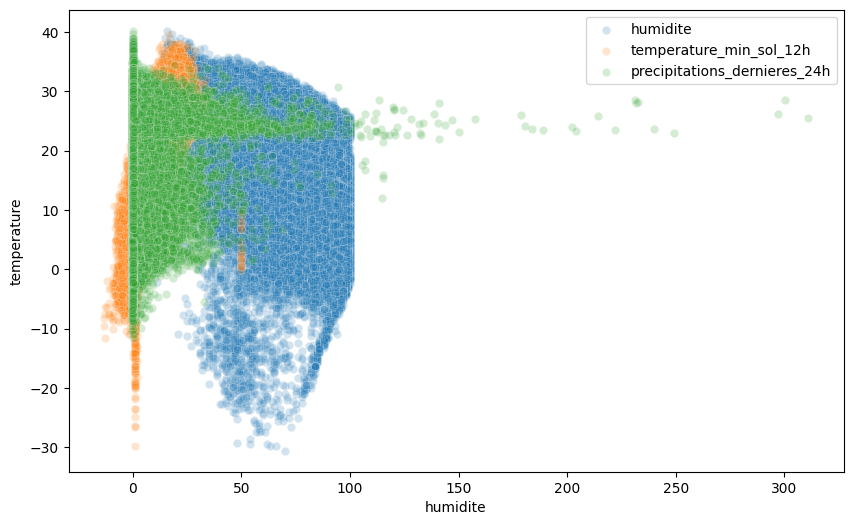

In [9]:

releve = pd.read_sql("SELECT * FROM releve_meteo", bdd)
releve.head()

# Conversion date
releve['date'] = pd.to_datetime(releve['date'])

# création année
releve['annee'] = releve['date'].dt.year

variables = [
    'humidite',
    'temperature_min_sol_12h',
    'precipitations_dernieres_24h'
]

# Kelvin -> Celsius
releve["temperature"] = releve["temperature"] - 273.15
releve["temperature_min_sol_12h"] = releve["temperature_min_sol_12h"] - 273.15



moy_an = releve.groupby('annee')[variables + ['temperature']].mean()

plt.figure(figsize=(10,6))

moy_an.plot(kind='bar')

plt.title("Evolution annuelle des conditions météorologiques")

plt.xlabel("Année")
plt.ylabel("Valeur moyenne")

plt.tight_layout()

plt.show()


plt.figure(figsize=(10,6))

for var in variables:

    sns.scatterplot(
        data=releve,
        x=var,
        y='temperature',
        alpha=0.2,
        label=var
    )

plt.title("Relation entre température et variables climatiques")

plt.xlabel("Variable climatique")

plt.ylabel("Température (°C)")

plt.legend()

plt.show()


annees = sorted(releve['annee'].unique())

for annee in annees:

    releve_annee = releve[releve['annee'] == annee]

    plt.figure(figsize=(10,6))

    for var in variables:

        sns.scatterplot(
            data=releve_annee,
            x=var,
            y='temperature',
            alpha=0.2,
            label=var
        )

    plt.title(f"Température par rapport aux autres variables climatiques- {année}")

    plt.xlabel("Variable climatique")

    plt.ylabel("Température (°C)")

    plt.legend()

    plt.show()

On observe une augmentation progressive de l’humidité moyenne entre 2022 et 2025 ainsi que des variations de température et de précipitations, traduisant une instabilité interannuelle du climat. Par ailleurs, les fortes précipitations sont majoritairement associées à des températures modérées, tandis que l’humidité présente une forte dispersion pour les températures basses, révélant des interactions complexes entre les variables climatiques.

Utilité pour la suite : Ces analyses justifient l’intégration de l’année comme variable explicative dans le modèle et permettent d’identifier les variables météorologiques les plus pertinentes pour améliorer la qualité des recommandations agricoles.

## Analyse temporelle

Hypothèse : La variation mensuelle des températures influence directement les périodes favorables aux différentes phases agricoles.

/tmp/ipykernel_643/2695052368.py:12: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



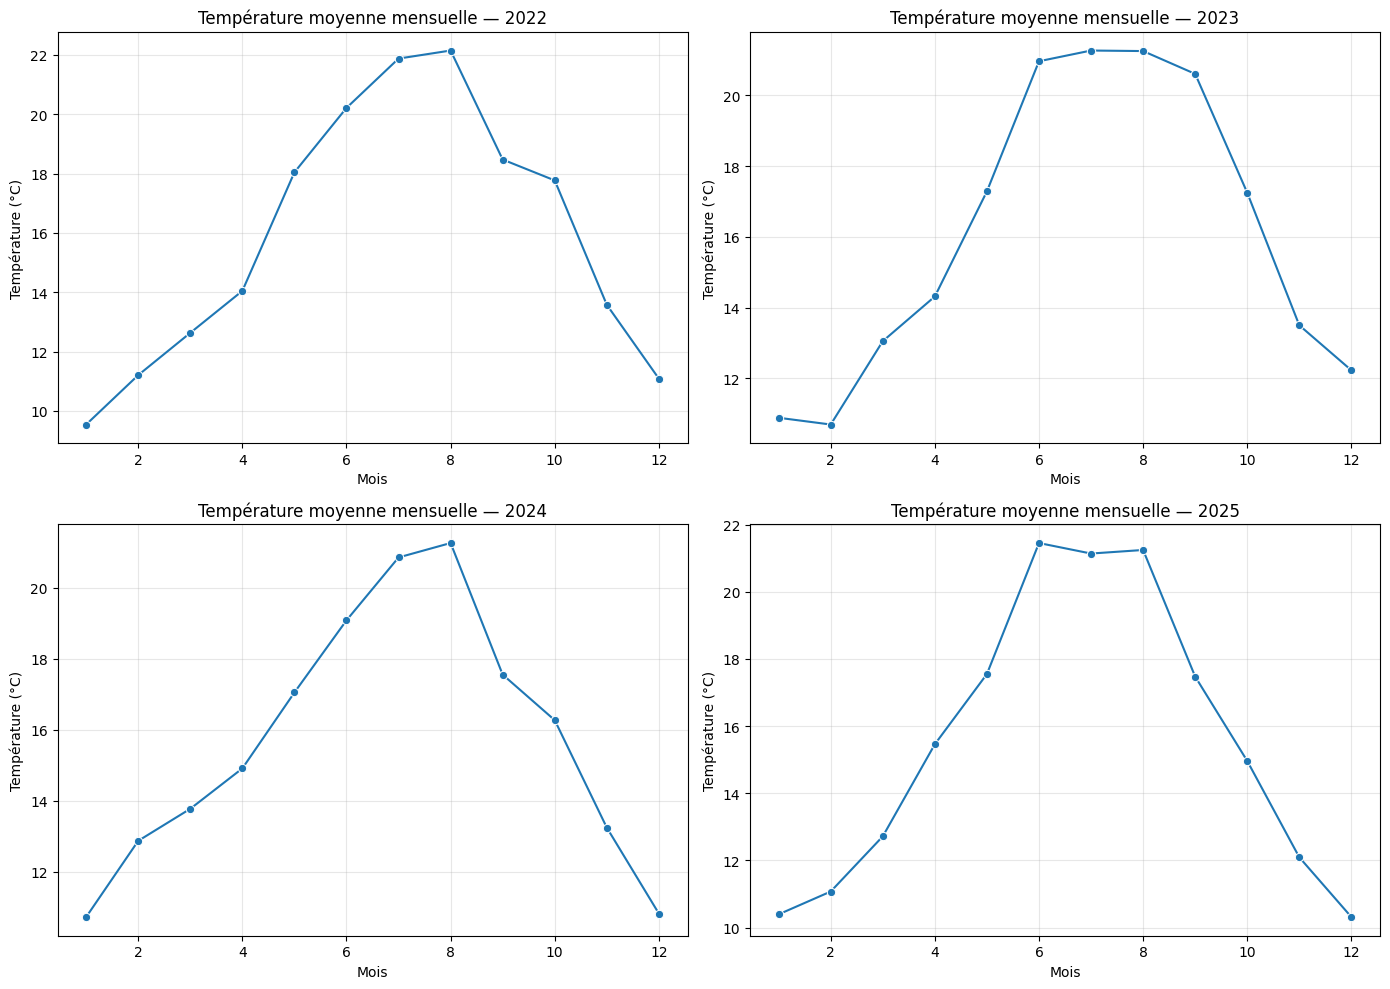

In [46]:
query = """
SELECT
    YEAR(date) AS annee,
    MONTH(date) AS mois,
    AVG(temperature) AS temperature_moyenne
FROM releve_meteo
WHERE YEAR(date) IN (2022,2023,2024,2025)
GROUP BY annee, mois
ORDER BY annee, mois;
"""

df = pd.read_sql(query, bdd)


df["temperature_moyenne"] = df["temperature_moyenne"] - 273.15



fig, axes = plt.subplots(2, 2, figsize=(14,10))

annees = [2022, 2023, 2024, 2025]

axes = axes.flatten()

for i, annee in enumerate(annees):

    df_annee = df[df["annee"] == annee]

    sns.lineplot(
        data=df_annee,
        x="mois",
        y="temperature_moyenne",
        marker="o",
        ax=axes[i]
    )

    axes[i].set_title(f"Température moyenne mensuelle — {annee}")

    axes[i].set_xlabel("Mois")

    axes[i].set_ylabel("Température (°C)")

    axes[i].grid(alpha=0.3)


plt.tight_layout()

plt.show()

On observe un cycle saisonnier stable sur les quatre années, avec des températures maximales entre juin et août (21–22°C) et minimales en hiver (10–11°C). Malgré quelques variations interannuelles, la dynamique saisonnière reste constante.

Utilité pour la suite : Cette stabilité permet d’utiliser le mois comme variable clé dans le modèle afin d’anticiper les périodes optimales de semis et de croissance selon les conditions climatiques observées.

## Analyse saisonnière

Hypothèse : Les conditions climatiques diffèrent selon les saisons et peuvent impacter la planification agricole.

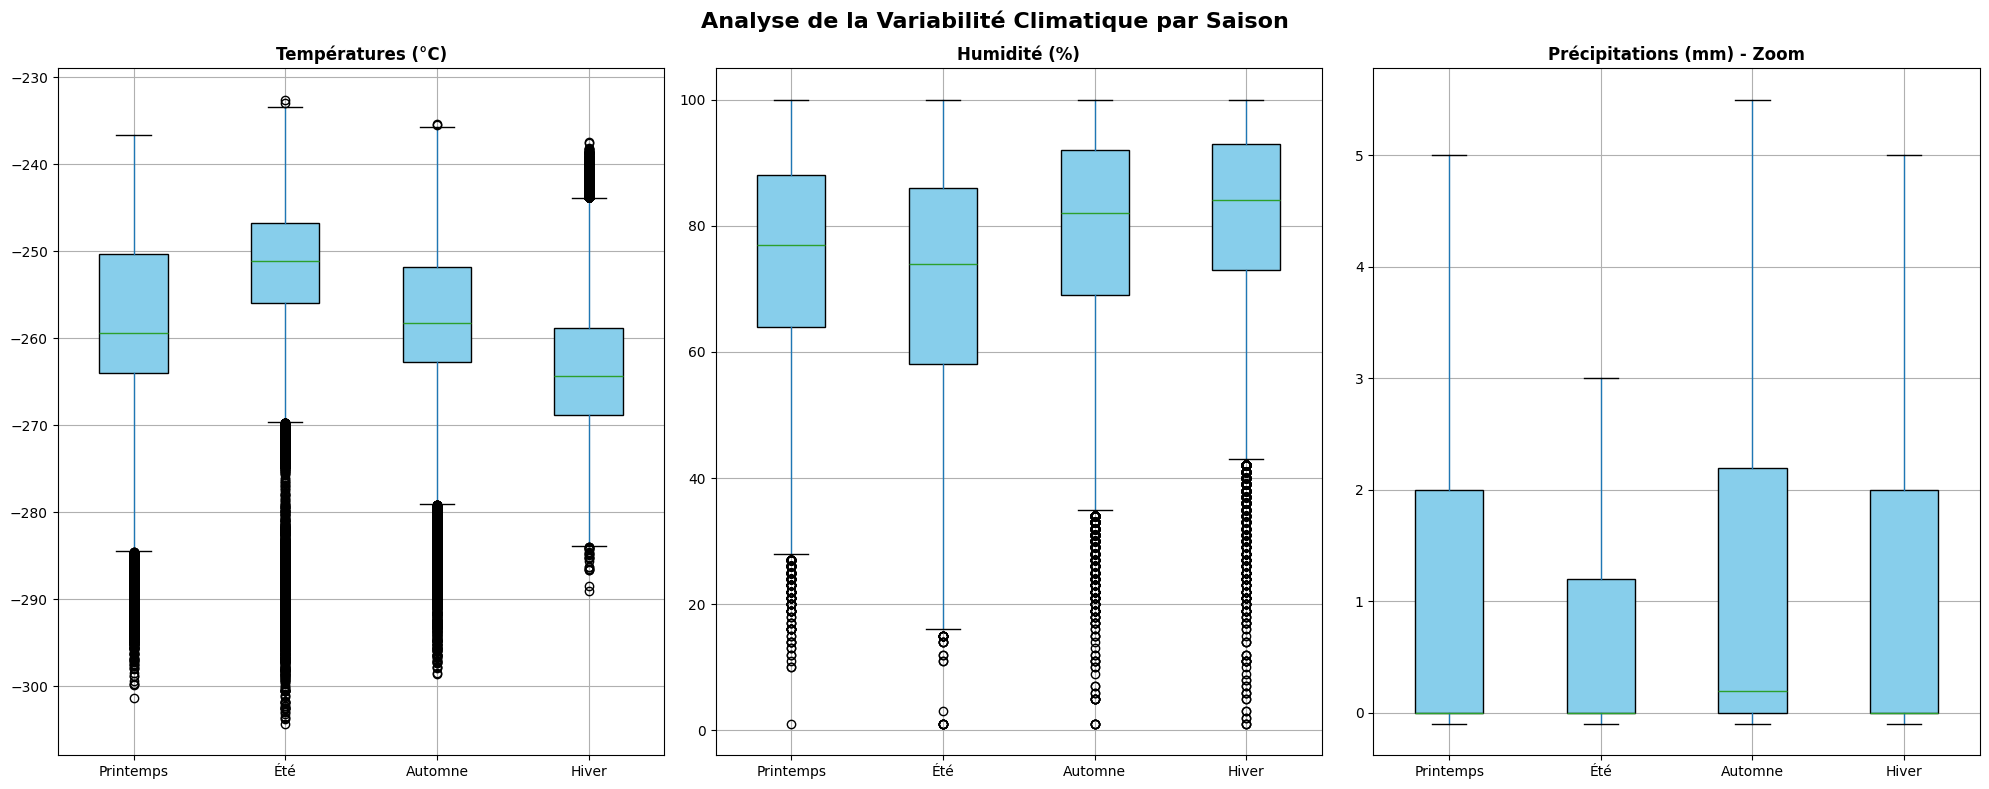

In [10]:
df_meteo = releve.copy()
df_meteo['date'] = pd.to_datetime(df_meteo['date'])
df_meteo['temperature'] = df_meteo['temperature'] - 273.15

def get_saison(d):
    m = d.month
    if m in [12, 1, 2]: return 'Hiver'
    if m in [3, 4, 5]:  return 'Printemps'
    if m in [6, 7, 8]:  return 'Été'
    return 'Automne'

df_meteo['saison'] = df_meteo['date'].apply(get_saison)

ordre = ['Printemps', 'Été', 'Automne', 'Hiver']
df_meteo['saison'] = pd.Categorical(df_meteo['saison'], categories=ordre, ordered=True)



plt.figure(figsize=(20, 8))

# Graphique 1 : Température
plt.subplot(1, 3, 1)
df_meteo.boxplot(column='temperature', by='saison', ax=plt.gca(), patch_artist=True,
                 boxprops=dict(facecolor='skyblue'))
plt.title('Températures (°C)', fontweight='bold')
plt.xlabel('')

plt.subplot(1, 3, 2)
df_meteo.boxplot(column='humidite', by='saison', ax=plt.gca(), patch_artist=True,
                 boxprops=dict(facecolor='skyblue'))
plt.title('Humidité (%)', fontweight='bold')
plt.xlabel('')

plt.subplot(1, 3, 3)
df_meteo.boxplot(column='precipitations_dernieres_24h', by='saison', ax=plt.gca(),
                 patch_artist=True, showfliers=False, # Le zoom est ici
                 boxprops=dict(facecolor='skyblue'))
plt.title('Précipitations (mm) - Zoom', fontweight='bold')
plt.xlabel('')

plt.suptitle('Analyse de la Variabilité Climatique par Saison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

On observe par exemple que les précipitations médianes sont proches de 0 mm en été alors qu’elles augmentent nettement en automne, et que l’humidité médiane dépasse 80 % en hiver contre environ 70 % en été. Ces écarts confirment une dynamique saisonnière marquée.

Utilité pour la suite : Ces différences justifient l’intégration de la saison et des variables climatiques dans le modèle afin d’adapter automatiquement les recommandations de semis et d’irrigation selon la période de l’année.

Hypothèse : Les conditions climatiques saisonnières influencent les risques agricoles et les besoins en irrigation.

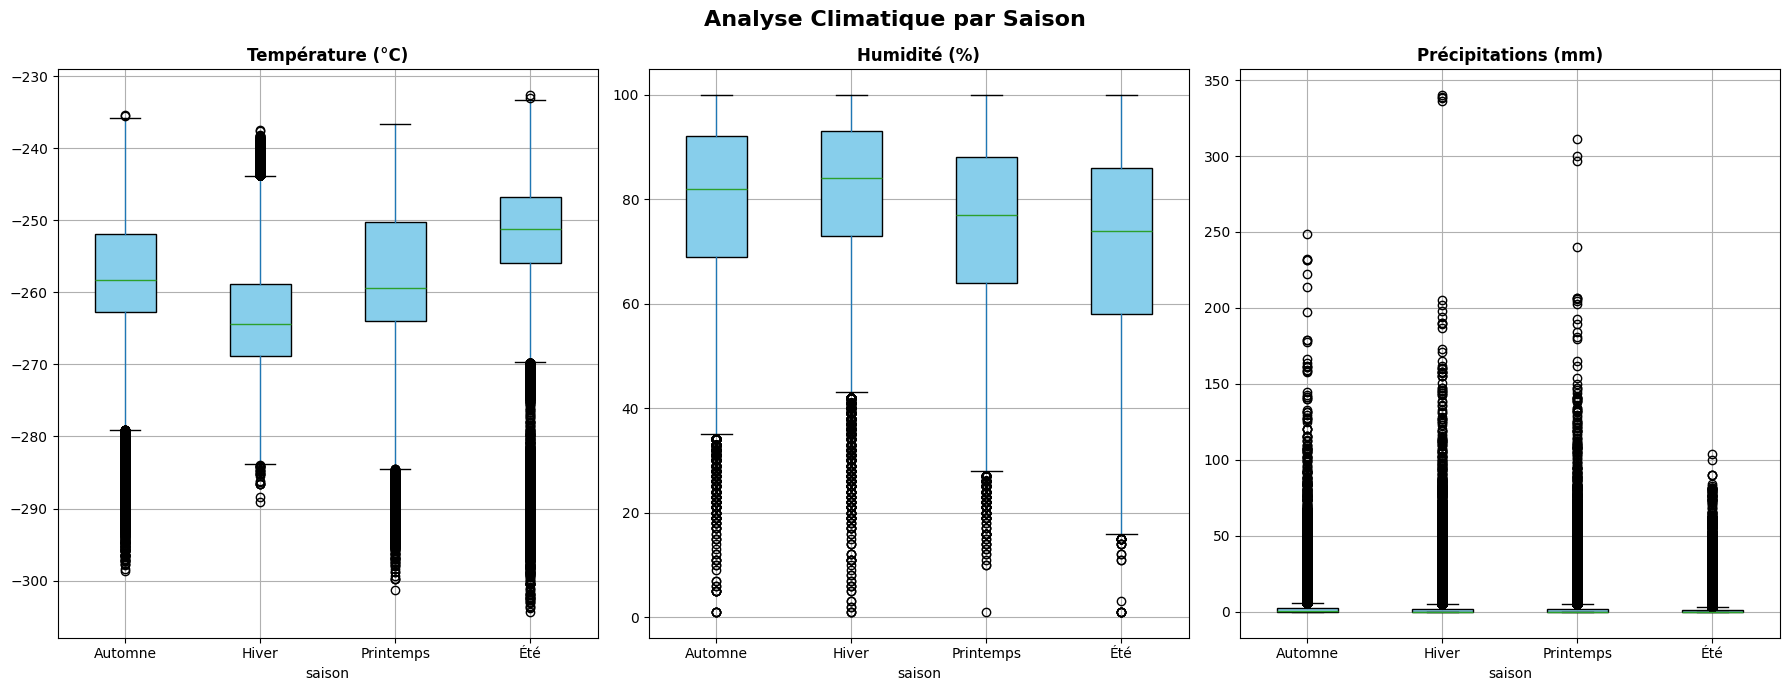

In [14]:
df_meteo = releve.copy()
df_meteo['date'] = pd.to_datetime(df_meteo['date'])
df_meteo['temperature'] = df_meteo['temperature'] - 273.15

def get_saison(d):
    m = d.month
    if m in [12, 1, 2]: return 'Hiver'
    if m in [3, 4, 5]:  return 'Printemps'
    if m in [6, 7, 8]:  return 'Été'
    return 'Automne'

df_meteo['saison'] = df_meteo['date'].apply(get_saison)


plt.figure(figsize=(18, 7))

plt.subplot(1, 3, 1)
df_meteo.boxplot(column='temperature', by='saison', ax=plt.gca(), patch_artist=True,
                 boxprops=dict(facecolor='skyblue'))
plt.title('Température (°C)', fontweight='bold')

plt.subplot(1, 3, 2)
df_meteo.boxplot(column='humidite', by='saison', ax=plt.gca(), patch_artist=True,
                 boxprops=dict(facecolor='skyblue'))
plt.title('Humidité (%)', fontweight='bold')

plt.subplot(1, 3, 3)
df_meteo.boxplot(column='precipitations_dernieres_24h', by='saison', ax=plt.gca(), patch_artist=True,
                 boxprops=dict(facecolor='skyblue'))
plt.title('Précipitations (mm)', fontweight='bold')

plt.suptitle('Analyse Climatique par Saison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

On observe que l’hiver présente les épisodes de précipitations les plus extrêmes (plus de 300 mm pour certains relevés), tandis que l’été reste majoritairement sec avec des valeurs proches de 0 mm. Parallèlement, l’humidité médiane diminue en été alors que les températures sont plus élevées, indiquant un risque accru de stress hydrique pour les cultures.

Utilité pour la suite : Cette variabilité confirme l’intérêt d’intégrer les précipitations et l’humidité dans le modèle afin d’anticiper les besoins d’irrigation et adapter les recommandations agricoles selon la saison.

## Évolution annuelle des températures

Hypothèse : Les températures moyennes évoluent d’une année à l’autre, ce qui peut modifier les périodes optimales de semis.

/tmp/ipykernel_643/3457771705.py:7: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



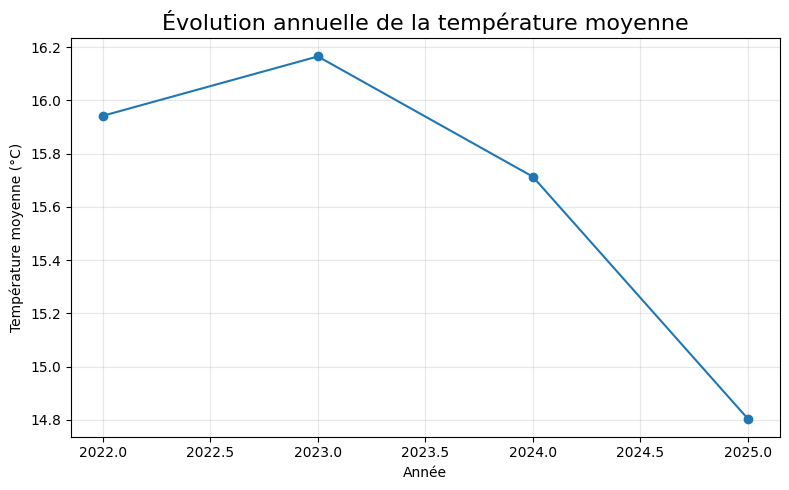

In [15]:

# EVOLUTION ANNUELLE DE LA TEMPERATURE MOYENNE


# Récupération données
df = pd.read_sql("""

SELECT
date,
temperature

FROM releve_meteo

""", bdd)

# Conversion date
df["date"] = pd.to_datetime(df["date"])

# Kelvin -> Celsius
df["temperature"] = df["temperature"] - 273.15

# Création variable année
df["annee"] = df["date"].dt.year

# Moyenne par année
moy_annee = df.groupby("annee")["temperature"].mean().reset_index()


plt.figure(figsize=(8,5))

plt.plot(
    moy_annee["annee"],
    moy_annee["temperature"],
    marker="o"
)

plt.title(
    "Évolution annuelle de la température moyenne",
    fontsize=16
)

plt.xlabel("Année")
plt.ylabel("Température moyenne (°C)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

On observe une hausse entre 2022 (15,9°C) et 2023 (16,2°C), suivie d’une baisse progressive jusqu’en 2025 (14,8°C). Cette variation de plus d’1°C en deux ans montre que les conditions climatiques ne sont pas stables.

Utilité pour la suite : Cette instabilité justifie l’intégration de la variable “année” dans le modèle afin d’adapter dynamiquement les recommandations agricoles aux évolutions climatiques récentes.

## Analyse mensuelle

Hypothèse : Les variables climatiques suivent une dynamique mensuelle identifiable permettant d’anticiper les périodes favorables ou à risque pour les cultures.

/tmp/ipykernel_643/592936643.py:5: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



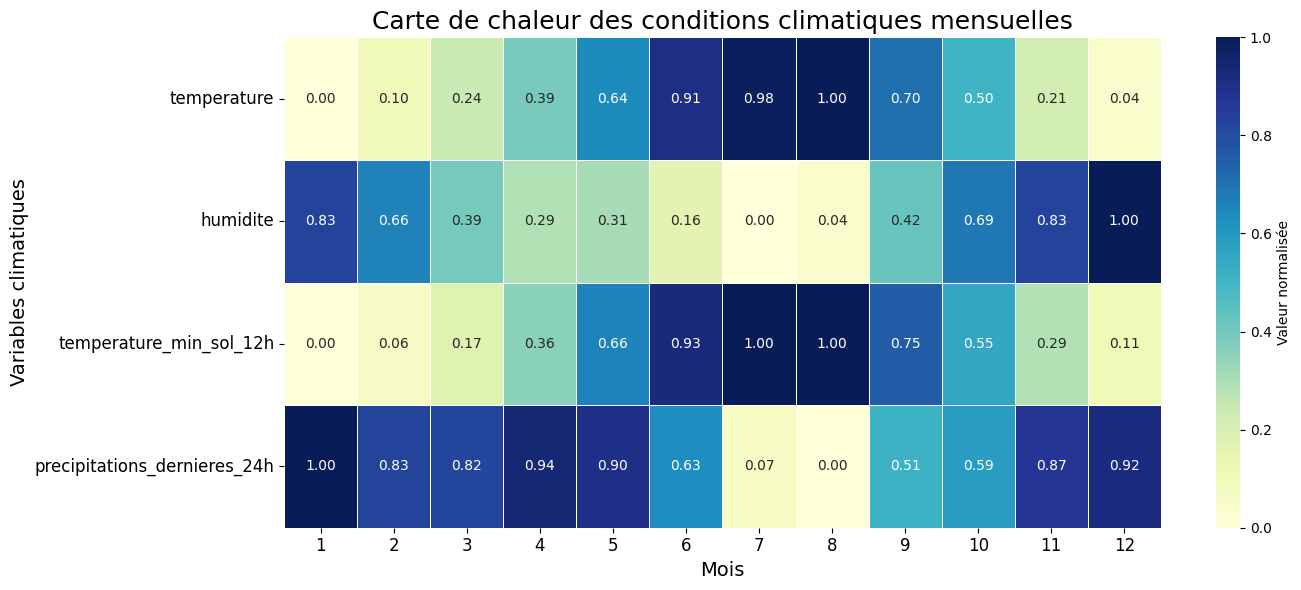

In [16]:

# RECUPERATION DONNEES METEO

releve = pd.read_sql("""
SELECT
date,
temperature,
humidite,
temperature_min_sol_12h,
precipitations_dernieres_24h
FROM releve_meteo
""", bdd)

releve.head()


# conversion date
releve['date'] = pd.to_datetime(releve['date'])

# création mois
releve['mois'] = releve['date'].dt.month

# Kelvin -> Celsius
releve["temperature"] = releve["temperature"] - 273.15
releve["temperature_min_sol_12h"] = releve["temperature_min_sol_12h"] - 273.15



variables = [
    'temperature',
    'humidite',
    'temperature_min_sol_12h',
    'precipitations_dernieres_24h'
]

moy_mois = releve.groupby('mois')[variables].mean().T

# assurer ordre mois 1 → 12
moy_mois = moy_mois.reindex(columns=range(1,13))


norm_mois = moy_mois.apply(
    lambda x: (x - x.min()) / (x.max() - x.min()),
    axis=1
)

# HEATMAP

plt.figure(figsize=(14,6))

sns.heatmap(
    norm_mois,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={'label': 'Valeur normalisée'}
)

plt.title(
    "Carte de chaleur des conditions climatiques mensuelles",
    fontsize=18
)

plt.xlabel("Mois", fontsize=14)
plt.ylabel("Variables climatiques", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()

plt.show()

On observe des températures et températures du sol maximales en juillet-août (≈1.00), tandis que les précipitations et l’humidité augmentent fortement en hiver (novembre à février). Cette opposition met en évidence des périodes sèches estivales et humides hivernales.

Utilité pour la suite : Cette saisonnalité mensuelle permet d’identifier les fenêtres optimales de semis et d’irrigation, et servira à intégrer le mois comme variable clé dans le modèle de recommandation agricole.

## Analyse spatiale

Hypothèse : Les températures moyennes varient spatialement et évoluent d’une année à l’autre, impactant les décisions agricoles locales.

In [17]:
# REQUETE SQL
query = """
SELECT
    s.station_id,
    s.nom,
    s.lat,
    s.lon,
    YEAR(r.date) as annee,
    AVG(r.temperature) as temp_moyenne

FROM station_meteo s

JOIN releve_meteo r
ON s.station_id = r.station_id

GROUP BY s.station_id, YEAR(r.date)
"""

df = pd.read_sql(query, bdd)

# CONVERSION KELVIN -> °C
df["temp_moyenne"] = df["temp_moyenne"] - 273.15

# FILTRE FRANCE
df = df[
    (df["lat"] >= 41) &
    (df["lat"] <= 51) &
    (df["lon"] >= -5) &
    (df["lon"] <= 9)
]

print("Nombre de stations en France :", df["station_id"].nunique())

# CARTE INTERACTIVE
fig = px.scatter_mapbox(
    df,
    lat="lat",
    lon="lon",
    color="temp_moyenne",
    size="temp_moyenne",
    animation_frame="annee",
    hover_name="nom",
    color_continuous_scale="RdYlBu_r",
    zoom=5,
    height=650
)

fig.update_layout(
    mapbox_style="open-street-map",
    mapbox_center={"lat": 46.5, "lon": 2.5},
    title="Température moyenne annuelle par station (°C) — France"
)

fig.show()

/tmp/ipykernel_643/2188159814.py:19: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



Nombre de stations en France : 90


On observe des températures plus élevées dans le sud (ex. côte méditerranéenne) et plus faibles dans le nord et l’est, avec des variations interannuelles visibles entre 2022 et 2025. Cela confirme une hétérogénéité climatique à la fois géographique et temporelle.

Utilité pour la suite : Cette analyse justifie une recommandation agricole personnalisée par localisation et par année dans l’application, plutôt qu’un planning unique à l’échelle nationale.

## Relations climatiques importantes

Hypothèse : Une augmentation des précipitations entraîne une hausse de l’humidité atmosphérique, influençant les risques agricoles.

/tmp/ipykernel_643/4288003297.py:6: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



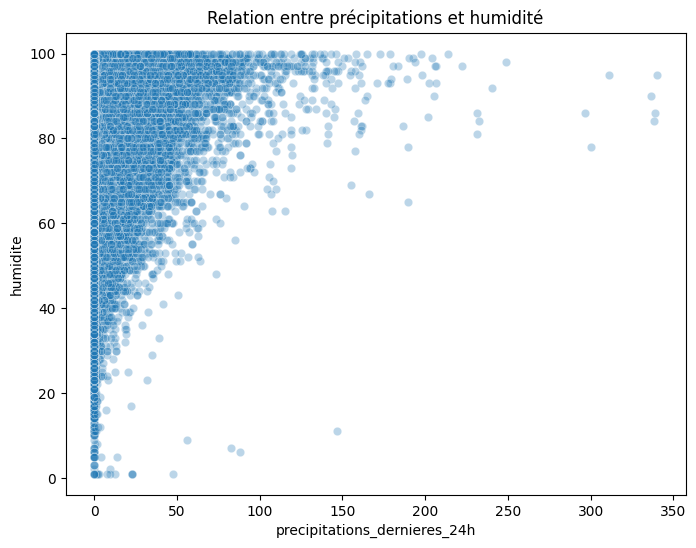

In [18]:
query = """
SELECT precipitations_dernieres_24h, humidite
FROM releve_meteo
"""

df = pd.read_sql(query, bdd)


plt.figure(figsize=(8,6))

sns.scatterplot(
data=df,
x="precipitations_dernieres_24h",
y="humidite",
alpha=0.3
)

plt.title("Relation entre précipitations et humidité")

plt.show()

On observe que les fortes précipitations sont presque toujours associées à une humidité élevée (>80 %), tandis que pour des précipitations proches de 0 mm, l’humidité devient très variable. Cela montre une relation positive mais non linéaire entre les deux variables.

Utilité pour la suite : Cette dépendance indique que les précipitations peuvent servir d’indicateur indirect d’humidité dans le modèle, utile pour anticiper les besoins d’irrigation ou les risques sanitaires liés à l’excès d’humidité.

Hypothèse : Certaines variables climatiques sont fortement corrélées entre elles, ce qui peut influencer la sélection des variables pour le modèle.

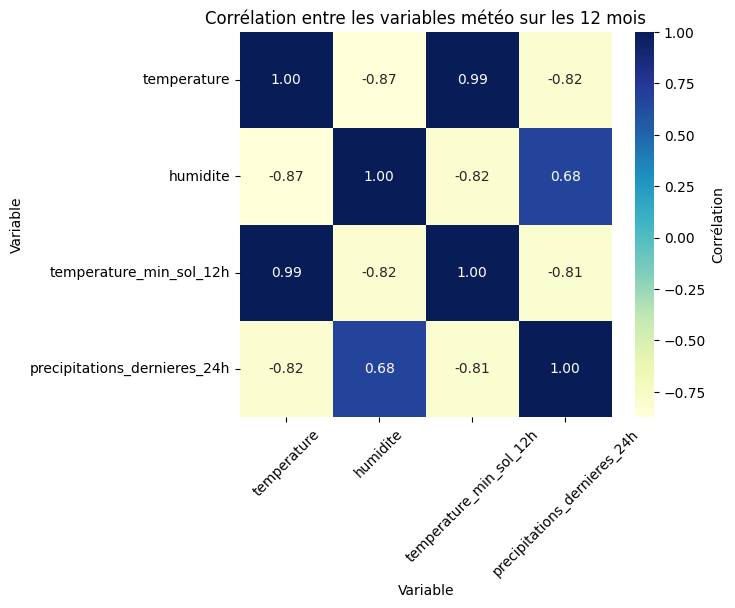

In [19]:
releve['date'] = pd.to_datetime(releve['date'])
releve['mois'] = releve['date'].dt.month

variables = [
    'temperature',
    'humidite',
    'temperature_min_sol_12h',
    'precipitations_dernieres_24h'
]

moy_mois = releve.groupby('mois')[variables].mean()

corr_vars = moy_mois.corr()


plt.figure(figsize=(6,5))
sns.heatmap(
    corr_vars,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={'label': 'Corrélation'}
)
plt.xticks(rotation=45)
plt.title("Corrélation entre les variables météo sur les 12 mois")
plt.xlabel("Variable")
plt.ylabel("Variable")
plt.show()

On observe une très forte corrélation positive entre la température et la température minimale du sol (0,99), tandis que l’humidité et les précipitations sont positivement liées (0,68) et négativement corrélées à la température. Cela montre une redondance partielle entre certaines variables.

Utilité pour la suite : Cette analyse permet d’éviter la colinéarité dans le modèle en sélectionnant uniquement les variables les plus pertinentes, améliorant ainsi la stabilité et les performances des prédictions.

# Analyse agronomique

## Contraintes thermiques cultures

Hypothèse : Les cultures présentent des besoins thermiques différents, nécessitant des recommandations spécifiques.

/tmp/ipykernel_643/3962976916.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_643/3962976916.py:23: UserWarning:

Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.



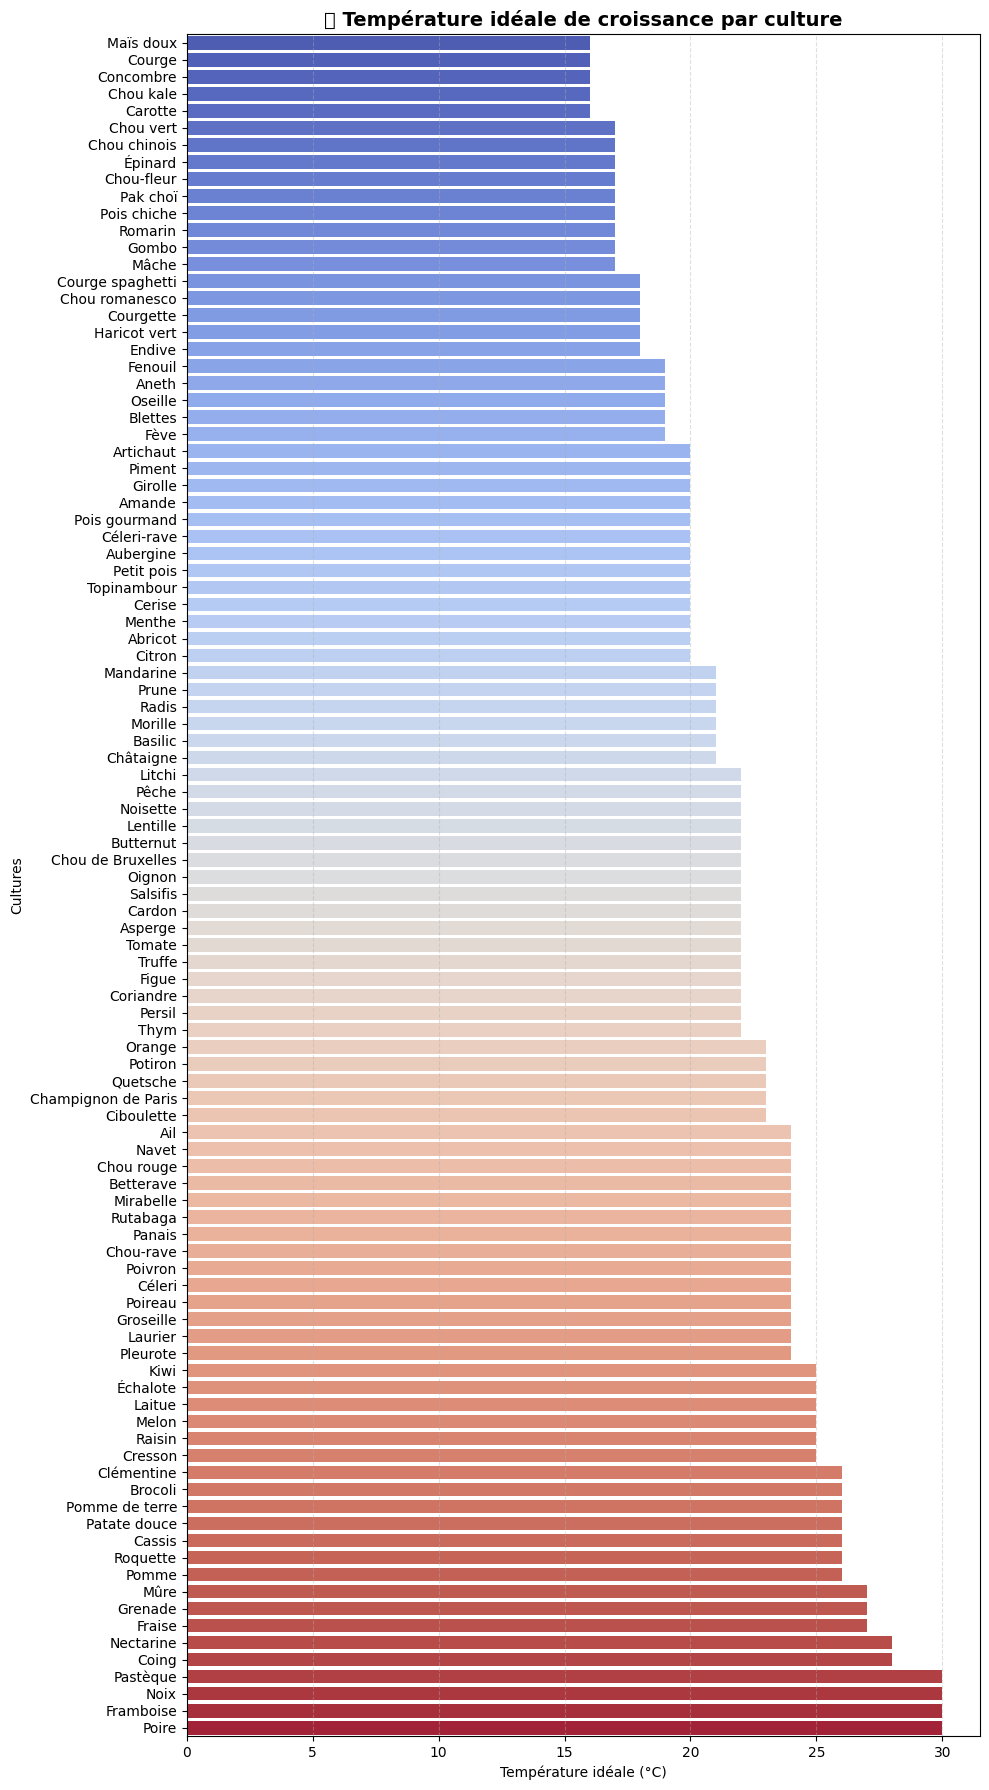

In [22]:
df = df.sort_values(by="t_ideale_croissance")

plt.figure(figsize=(10,18))

ax = sns.barplot(
    data=df,
    y="nom_culture",
    x="t_ideale_croissance",
    palette="coolwarm"
)

plt.xlabel("Température idéale (°C)")
plt.ylabel("Cultures")

plt.title(
" Température idéale de croissance par culture",
fontsize=14,
fontweight="bold"
)

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

On observe des écarts pouvant dépasser 8–10°C entre certaines cultures (≈22°C pour certaines contre ≈30°C pour d’autres), ce qui confirme une forte hétérogénéité des exigences thermiques.

Utilité pour la suite : Cette différence justifie que le modèle croise la température locale avec la température idéale propre à chaque culture pour générer un planning réellement personnalisé.

Hypothèse : Les cultures se distinguent clairement selon leurs besoins thermiques, ce qui implique des recommandations différenciées selon le climat local.

/tmp/ipykernel_643/2721364565.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




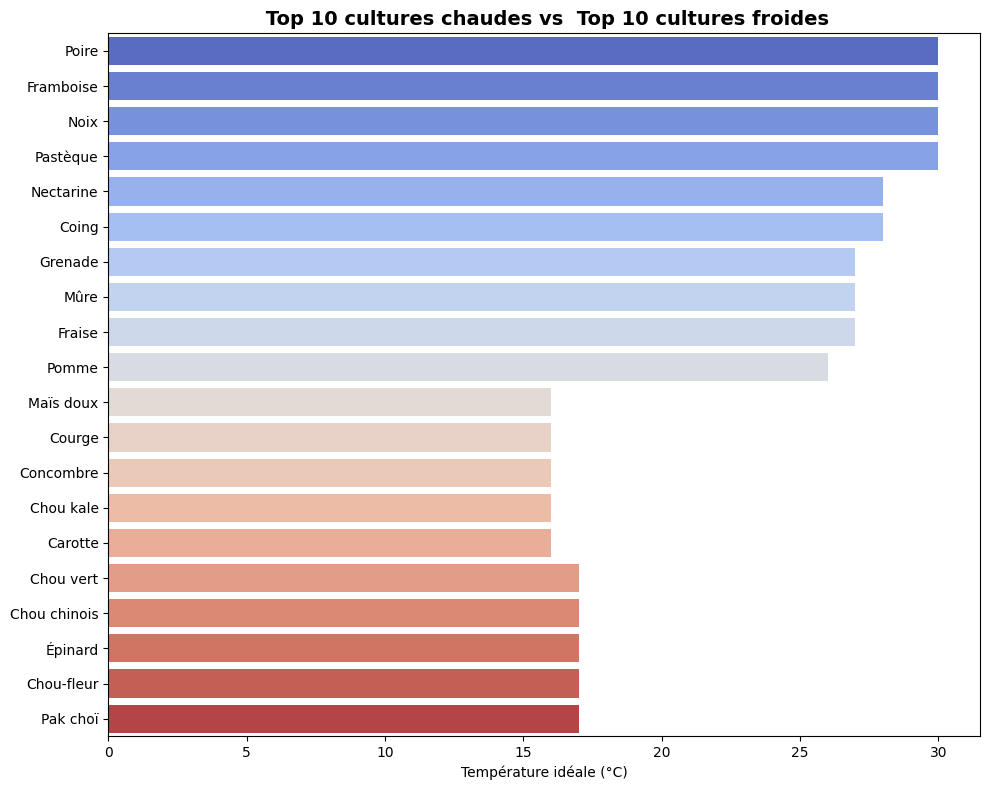

In [24]:
top_chaud = df.sort_values("t_ideale_croissance", ascending=False).head(10)
top_froid = df.sort_values("t_ideale_croissance").head(10)

df_focus = pd.concat([top_chaud, top_froid])

plt.figure(figsize=(10,8))

sns.barplot(
    data=df_focus,
    y="nom_culture",
    x="t_ideale_croissance",
    palette="coolwarm"
)

plt.xlabel("Température idéale (°C)")
plt.ylabel("")

plt.title(
" Top 10 cultures chaudes vs  Top 10 cultures froides",
fontsize=14,
fontweight="bold"
)

plt.tight_layout()
plt.show()

On observe un écart marqué entre les cultures chaudes (ex. pastèque ≈30°C) et les cultures froides (ex. épinard ou chou ≈16°C), soit près de 14°C de différence. Cette séparation nette confirme que toutes les cultures ne peuvent pas être recommandées dans les mêmes conditions climatiques.

Utilité pour la suite : Cette distinction permettra au modèle de filtrer automatiquement les cultures compatibles avec la température moyenne locale, évitant ainsi des recommandations inadaptées.

Hypothèse : Plus la température idéale d’une culture s’éloigne de la température moyenne française (~12,1°C), plus son adaptation climatique devient difficile.

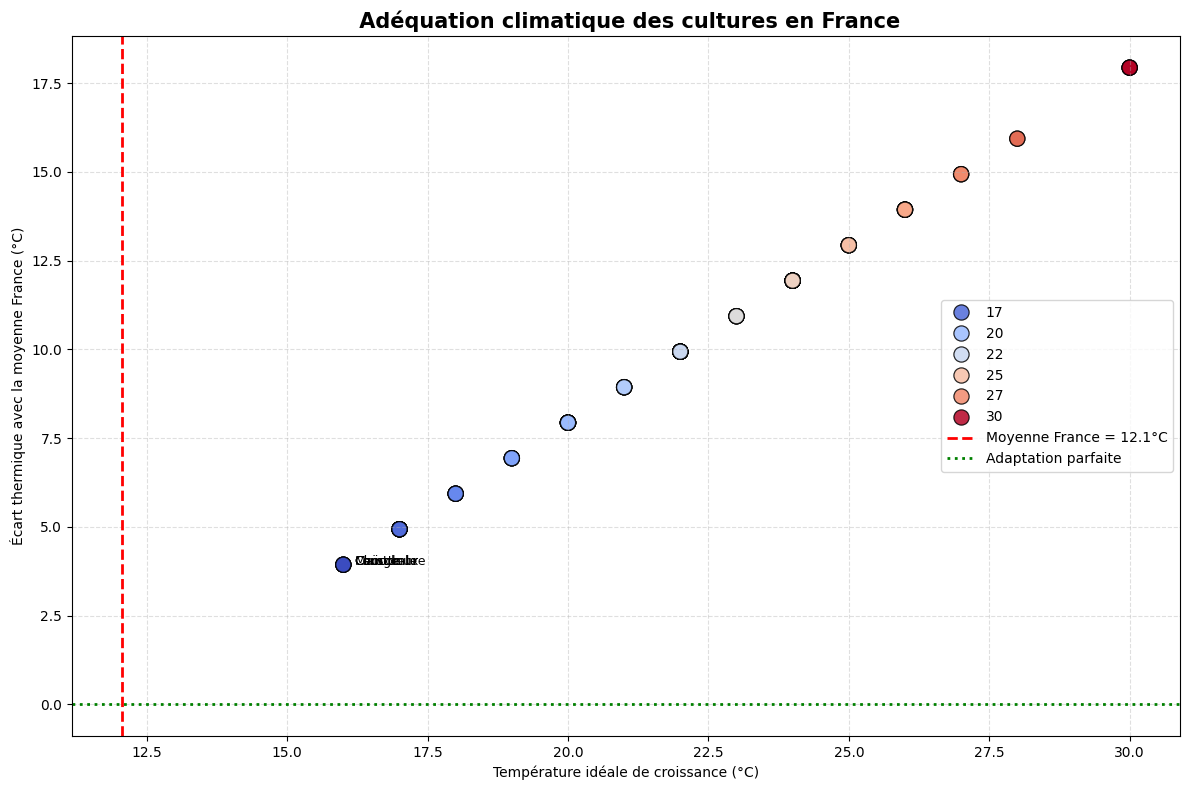

In [29]:
plt.figure(figsize=(12,8))

# Scatter principal
sns.scatterplot(
    data=df_culture,
    x="t_ideale_croissance",
    y="ecart_thermique",
    hue=df_culture["t_ideale_croissance"],
    palette="coolwarm",
    s=120,
    edgecolor="black",
    alpha=0.85
)

# Ligne verticale moyenne France
plt.axvline(
    temp_moyenne_france,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Moyenne France = {temp_moyenne_france:.1f}°C"
)

# Ligne horizontale adaptation parfaite
plt.axhline(
    0,
    color="green",
    linestyle=":",
    linewidth=2,
    label="Adaptation parfaite"
)

# Annoter les 5 cultures les plus adaptées
top5 = df_culture.nsmallest(5, "ecart_thermique")

for _, row in top5.iterrows():
    plt.text(
        row["t_ideale_croissance"] + 0.2,
        row["ecart_thermique"],
        row["nom_culture"],
        fontsize=9
    )

plt.xlabel("Température idéale de croissance (°C)")
plt.ylabel("Écart thermique avec la moyenne France (°C)")

plt.title(
" Adéquation climatique des cultures en France",
fontsize=15,
fontweight="bold"
)

plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

On observe que les cultures nécessitant des températures élevées (25–30°C) présentent un écart thermique important avec le climat moyen français, contrairement aux cultures proches de 16–18°C qui restent plus adaptées.

Utilité pour la suite : Cette analyse permet au modèle de filtrer automatiquement les cultures compatibles avec le climat local et d’éviter des recommandations à fort risque d’échec agronomique.

## Compatibilité culture climat

Hypothèse : La compatibilité entre température mensuelle et plages thermiques idéales détermine les périodes favorables à la culture.

/tmp/ipykernel_643/199765999.py:1: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.

/tmp/ipykernel_643/199765999.py:3: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



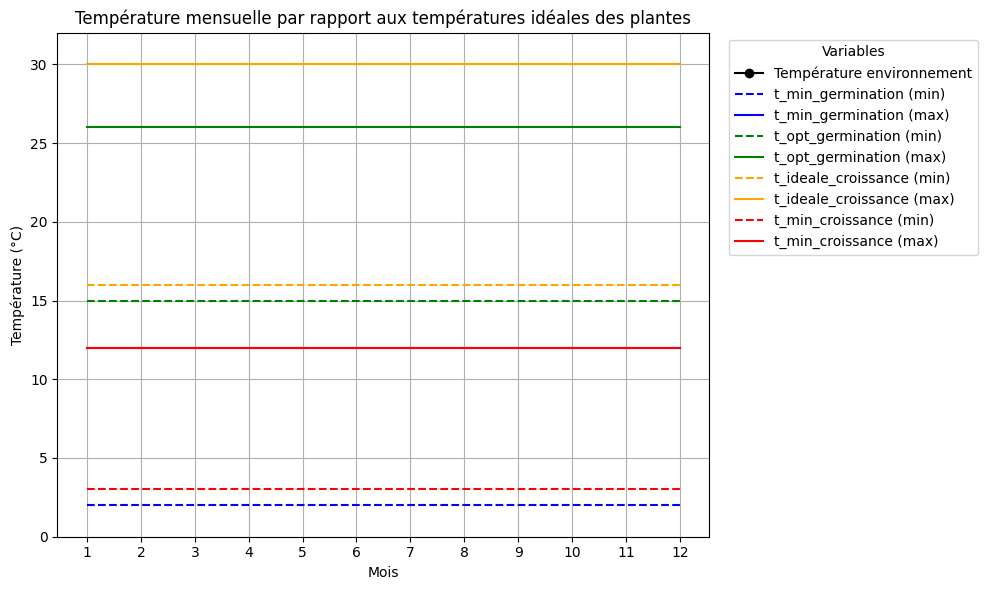

In [26]:
culture = pd.read_sql("SELECT * FROM culture", bdd)

contrainte = pd.read_sql("SELECT * FROM contrainte_temperature", bdd)

culture = culture.merge(contrainte, on='id_culture')

culture.head()



releve['temperature'] = releve['temperature'] - 273.15
releve['temperature'] = releve['temperature'].round(1)

releve['date'] = pd.to_datetime(releve['date'])
releve['mois'] = releve['date'].dt.month

moy_mois = releve.groupby('mois')['temperature'].mean()



culture_vars = [
    't_min_germination',
    't_opt_germination',
    't_ideale_croissance',
    't_min_croissance'
]

plot_tmp = pd.DataFrame({
    'mois': moy_mois.index,
    'temperature_env': moy_mois.values
})

plt.figure(figsize=(10,6))

# Environment temperature
sns.lineplot(
    data=plot_tmp,
    x='mois',
    y='temperature_env',
    marker='o',
    color='black',
    label="Température environnement"
)

min_vals = culture[culture_vars].min().fillna(0)
max_vals = culture[culture_vars].max().fillna(0)

colors = ['blue','green','orange','red']
legend_elements = [Line2D([0], [0], color='black', marker='o', label='Température environnement')]

for var, color in zip(culture_vars, colors):
    # Min line
    plt.plot(
        plot_tmp['mois'],
        [min_vals[var]] * len(plot_tmp),
        linestyle='--',
        color=color
    )
    # Max line
    plt.plot(
        plot_tmp['mois'],
        [max_vals[var]] * len(plot_tmp),
        linestyle='-',
        color=color
    )

    # Add legend manually
    legend_elements.append(Line2D([0], [0], color=color, linestyle='--', label=f"{var} (min)"))
    legend_elements.append(Line2D([0], [0], color=color, linestyle='-', label=f"{var} (max)"))

plt.title("Température mensuelle par rapport aux températures idéales des plantes")
plt.xlabel("Mois")
plt.ylabel("Température (°C)")
plt.xticks(range(1,13))
plt.ylim(0, max(plot_tmp['temperature_env'].max(), max_vals.max()) + 2)
plt.legend(handles=legend_elements, bbox_to_anchor=(1.02,1), loc='upper left', title="Variables")
plt.grid(True)
plt.tight_layout()
plt.show()

On observe que certaines plages optimales (ex. croissance idéale autour de 26–30°C) ne sont atteintes que durant les mois les plus chauds, tandis que les seuils minimaux de germination (~2–3°C) sont largement dépassés sur une grande partie de l’année. Cela permet d’identifier les mois réellement compatibles avec chaque phase de développement.

Utilité pour la suite : Ce croisement entre climat réel et contraintes biologiques constitue la base logique du système de recommandation automatique des périodes de semis et de croissance.

## Analyse sols

Hypothèse : Les sols peuvent être regroupés en profils distincts (sableux, équilibrés, argileux) influençant l’adaptation des cultures.

/tmp/ipykernel_643/4125014204.py:22: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



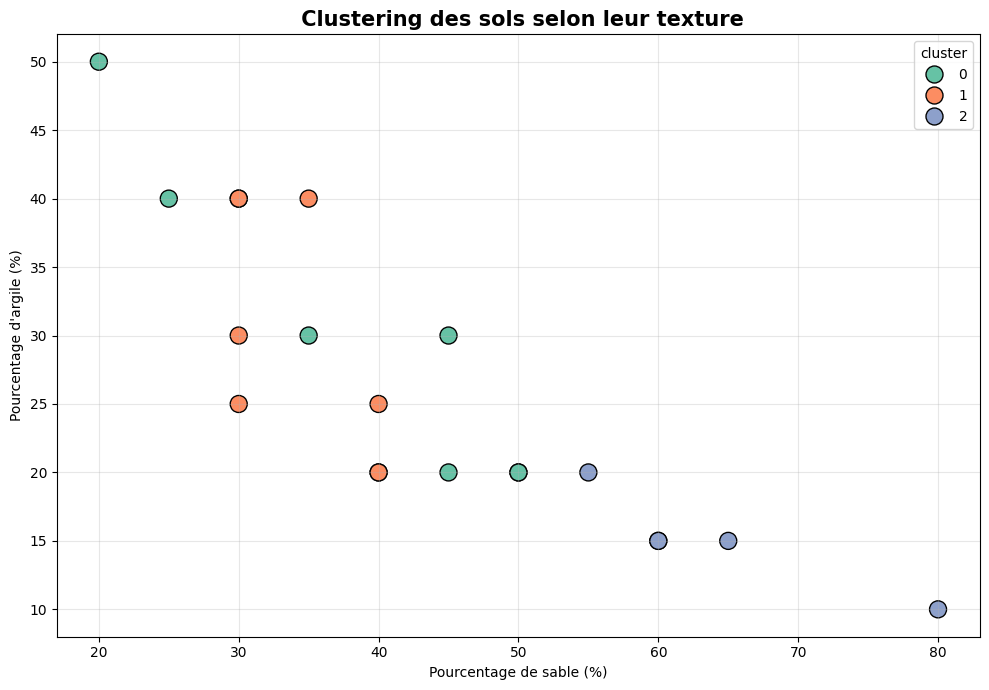

In [49]:

import pandas as pd
import mysql.connector
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


query = """
SELECT
    soil_id,
    soil_name,
    sand_pct,
    silt_pct,
    clay_pct,
    pH,
    organic_matter_pct,
    water_holding_capacity
FROM type_sol
"""

df_sol = pd.read_sql(query, bdd)


# =====================================================
# PRÉPARATION DES DONNÉES
# =====================================================

features = [
    "sand_pct",
    "silt_pct",
    "clay_pct",
    "pH",
    "organic_matter_pct",
    "water_holding_capacity"
]

X = df_sol[features]

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df_sol["cluster"] = kmeans.fit_predict(X_scaled)



plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df_sol,
    x="sand_pct",
    y="clay_pct",
    hue="cluster",
    s=150,
    palette="Set2",
    edgecolor="black"
)

plt.title(
    " Clustering des sols selon leur texture",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Pourcentage de sable (%)")
plt.ylabel("Pourcentage d'argile (%)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

On observe trois groupes clairs :

sols très sableux (60–80% sable, faible argile),

sols intermédiaires (~40–50% sable),

sols plus argileux (20–30% sable, 40–50% argile).

Utilité pour la suite : Ce clustering permet d’associer automatiquement chaque culture aux sols compatibles et d’améliorer la recommandation agronomique.

# Analyse avancée

Hypothèse : Les données météo peuvent être regroupées en régimes climatiques distincts (froid/humide, tempéré, chaud/sec).

/tmp/ipykernel_643/1146479488.py:39: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.

/tmp/ipykernel_643/1146479488.py:118: UserWarning:

Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.



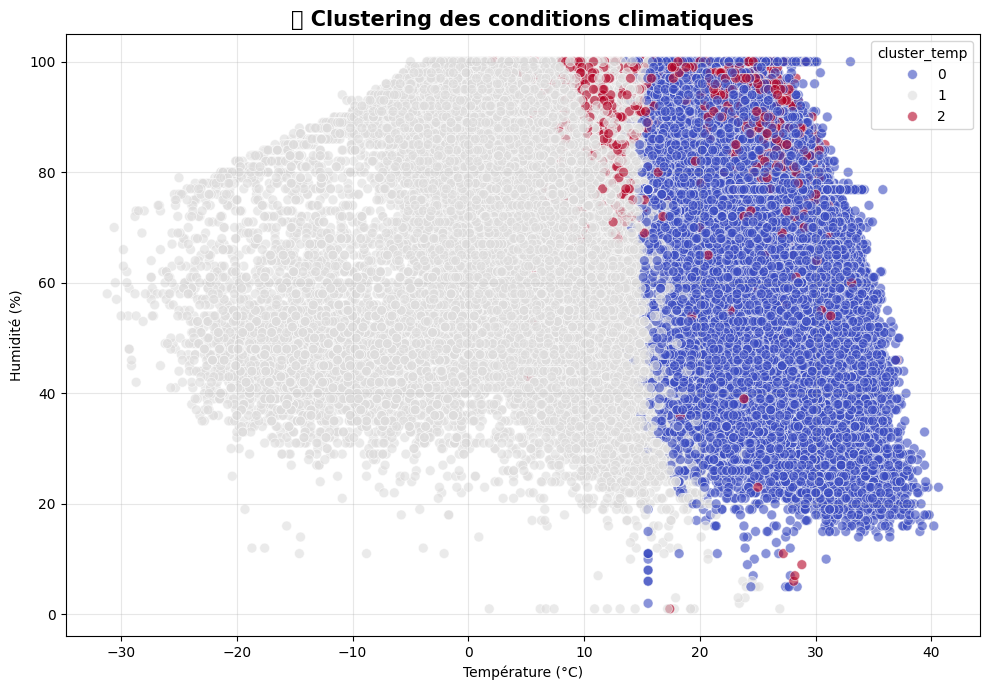

In [53]:


import pandas as pd
import mysql.connector
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler




query = """
SELECT
    temperature,
    point_de_rose,
    humidite,
    temperature_min_sol_12h,
    precipitations_dernieres_24h
FROM releve_meteo
"""

df = pd.read_sql(query, bdd)



df["temperature"] = df["temperature"] - 273.15
df["point_de_rose"] = df["point_de_rose"] - 273.15
df["temperature_min_sol_12h"] = df["temperature_min_sol_12h"] - 273.15



# Remplacement des NaN par la moyenne des colonnes
df = df.fillna(df.mean(numeric_only=True))



features = [
    "temperature",
    "point_de_rose",
    "humidite",
    "temperature_min_sol_12h",
    "precipitations_dernieres_24h"
]

X = df[features]

# Normalisation (indispensable pour KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


kmeans = KMeans(
    n_clusters=3,        # tu peux tester 4 si tu veux
    random_state=42,
    n_init=10
)

df["cluster_temp"] = kmeans.fit_predict(X_scaled)



plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x="temperature",
    y="humidite",
    hue="cluster_temp",
    palette="coolwarm",
    alpha=0.6,
    s=50
)

plt.title(
    "🌡️ Clustering des conditions climatiques",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Température (°C)")
plt.ylabel("Humidité (%)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

On distingue trois groupes : un climat froid (températures négatives à faibles), un climat tempéré (~10–20°C) et un climat chaud (>20°C). La séparation nette montre que les conditions météo se structurent en profils climatiques cohérents.

Utilité pour la suite : Ce clustering permet d’associer chaque période à un type climatique et d’adapter automatiquement les recommandations de cultures selon le régime observé.

# Clustering environnemental

Hypothèse : La combinaison des caractéristiques du sol et des conditions climatiques permet d’identifier des environnements agricoles distincts.

/tmp/ipykernel_643/3699667928.py:29: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.

/tmp/ipykernel_643/3699667928.py:43: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



NaN avant nettoyage :
soil_id                    0
soil_name                  0
sand_pct                   0
silt_pct                   0
clay_pct                   0
pH                         0
organic_matter_pct         0
water_holding_capacity     0
station_id                 0
temperature_moyenne        0
humidite_moyenne          40
precipitation_moyenne     60
dtype: int64
NaN après nettoyage :
soil_id                   0
soil_name                 0
sand_pct                  0
silt_pct                  0
clay_pct                  0
pH                        0
organic_matter_pct        0
water_holding_capacity    0
station_id                0
temperature_moyenne       0
humidite_moyenne          0
precipitation_moyenne     0
dtype: int64


/tmp/ipykernel_643/3699667928.py:113: UserWarning:

Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.



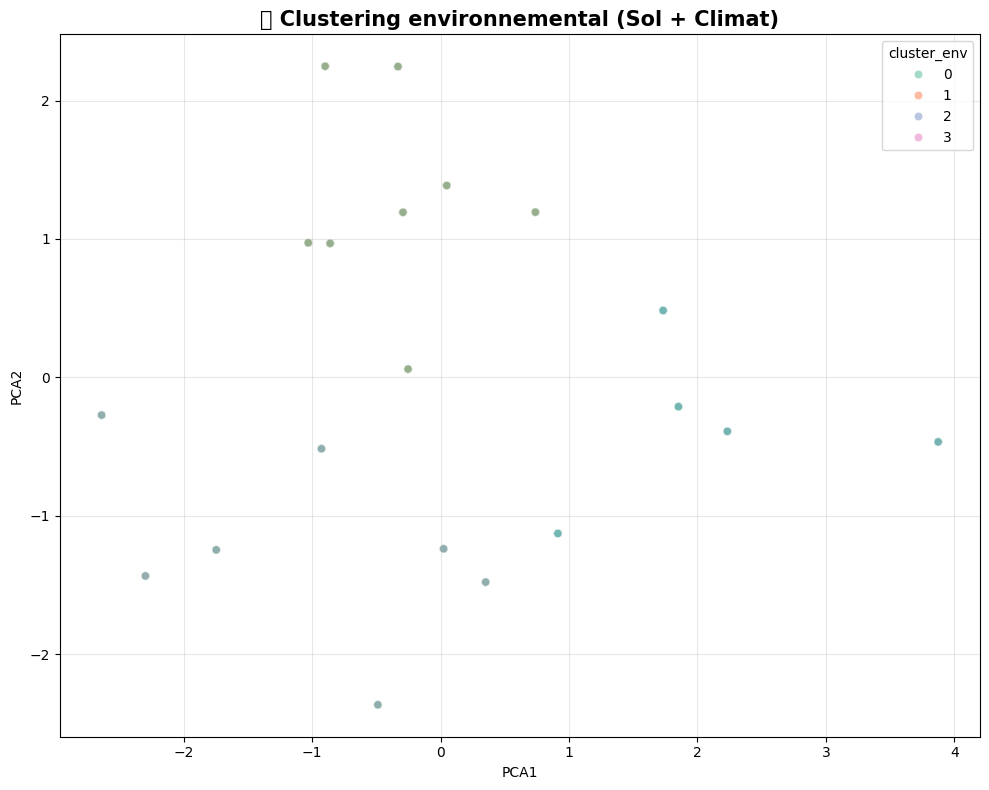

In [58]:


import pandas as pd
import mysql.connector
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


# DONNÉES SOLS

query_sol = """
SELECT
    soil_id,
    soil_name,
    sand_pct,
    silt_pct,
    clay_pct,
    pH,
    organic_matter_pct,
    water_holding_capacity
FROM type_sol
"""

df_sol = pd.read_sql(query_sol, bdd)



query_climat = """
SELECT
    station_id,
    AVG(temperature) AS temperature_moyenne,
    AVG(humidite) AS humidite_moyenne,
    AVG(precipitations_dernieres_24h) AS precipitation_moyenne
FROM releve_meteo
GROUP BY station_id
"""

df_climat = pd.read_sql(query_climat, bdd)

df_climat["temperature_moyenne"] -= 273.15



df_env = df_sol.merge(df_climat, how="cross")


# Vérifier
print("NaN avant nettoyage :")
print(df_env.isnull().sum())

# Remplacement par moyenne colonne
df_env = df_env.fillna(df_env.mean(numeric_only=True))

print("NaN après nettoyage :")
print(df_env.isnull().sum())


features = [
    "sand_pct",
    "silt_pct",
    "clay_pct",
    "pH",
    "organic_matter_pct",
    "water_holding_capacity",
    "temperature_moyenne",
    "humidite_moyenne",
    "precipitation_moyenne"
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_env[features])

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df_env["cluster_env"] = kmeans.fit_predict(X_scaled)

# PCA POUR VISUALISATION

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_env["PCA1"] = X_pca[:,0]
df_env["PCA2"] = X_pca[:,1]


plt.figure(figsize=(10,8))

sns.scatterplot(
    data=df_env,
    x="PCA1",
    y="PCA2",
    hue="cluster_env",
    palette="Set2",
    alpha=0.6
)

plt.title(
    "🌍 Clustering environnemental (Sol + Climat)",
    fontsize=15,
    fontweight="bold"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

On observe quatre groupes séparés dans l’espace PCA, montrant que certaines combinaisons sol-climat forment des profils environnementaux cohérents (ex : sol sableux + climat chaud vs sol argileux + climat tempéré).

Utilité pour la suite : Ce clustering est stratégique : il permet d’associer directement chaque environnement à un ensemble de cultures optimales, rendant la recommandation plus précise que l’analyse du sol ou du climat séparément.

# Visualisations décisionnelles

Hypothèse : Le jeu de données contient une proportion équilibrée de types de cultures.

type_culture
Légume    70
Fruit     30
Name: count, dtype: int64


/tmp/ipykernel_643/3956683710.py:4: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



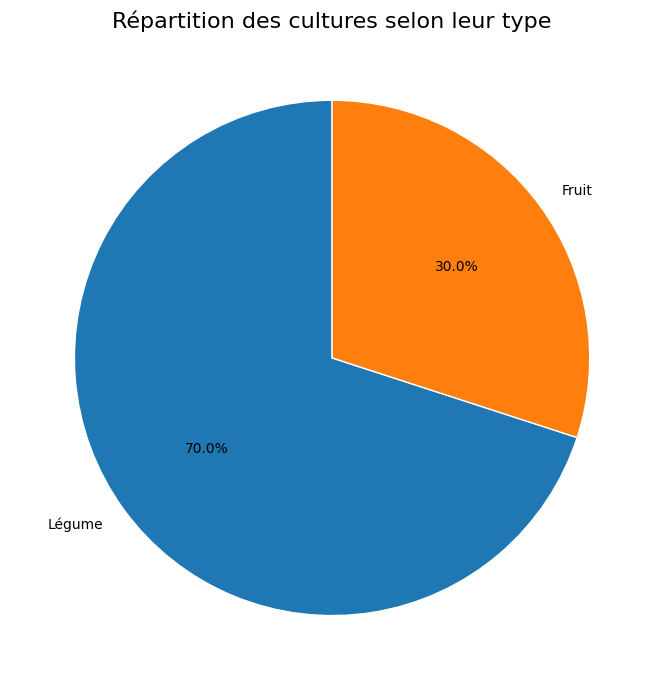

In [31]:

# DIVERSITE DES CULTURES

# Récupération des cultures
df_culture = pd.read_sql("""

SELECT
nom_culture,
type_culture

FROM culture

""", bdd)

# Comptage par type
repartition = df_culture["type_culture"].value_counts()

print(repartition)

# VISUALISATION

plt.figure(figsize=(7,7))

plt.pie(
    repartition,
    labels=repartition.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white"}
)

plt.title(
    "Répartition des cultures selon leur type",
    fontsize=16
)

plt.tight_layout()

plt.show()

On observe que les légumes représentent 70 % du dataset contre 30 % pour les fruits, indiquant un déséquilibre en faveur des cultures maraîchères.

Utilité pour la suite : Cette information est surtout utile pour comprendre la structure du dataset et anticiper un éventuel biais si un modèle est entraîné par type de culture.

Hypothèse : Les cultures peuvent être regroupées selon leurs besoins thermiques afin d’identifier des profils climatiques similaires.

In [34]:
import pandas as pd
import mysql.connector
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

/tmp/ipykernel_643/4069447195.py:11: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



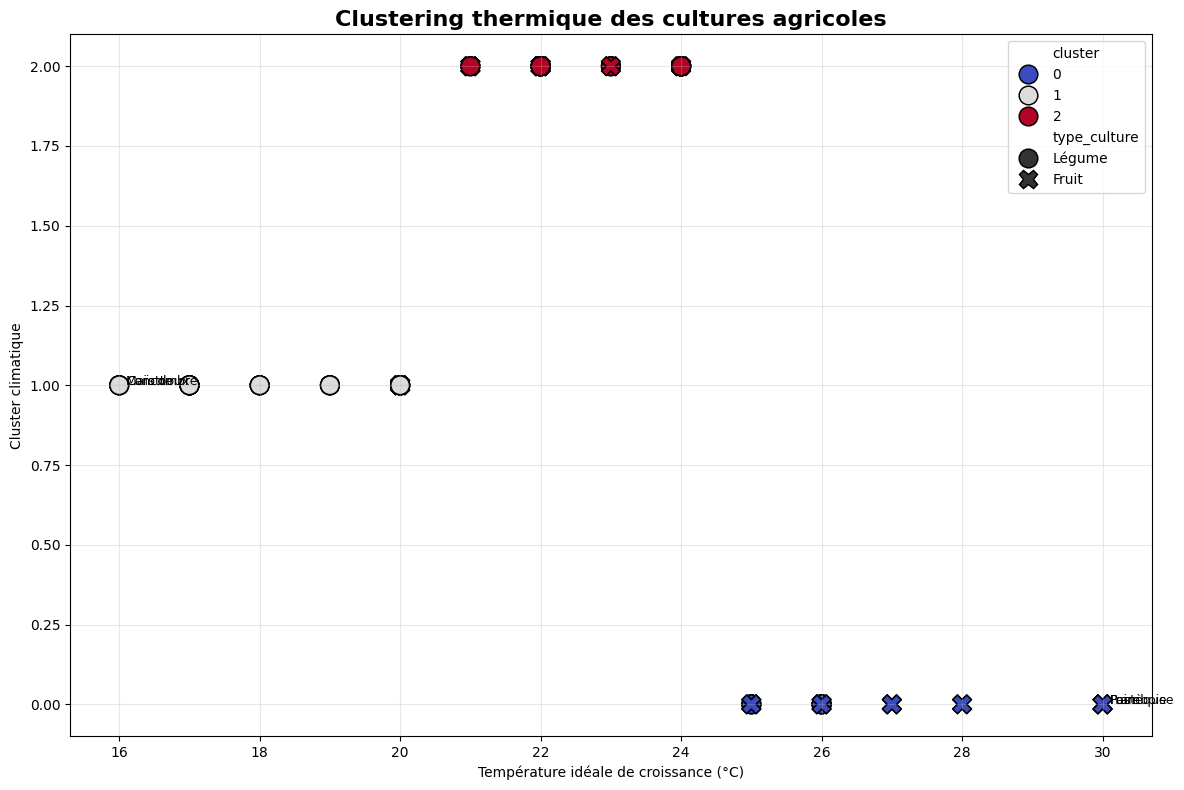

In [37]:
query = """
SELECT
    c.nom_culture,
    c.type_culture,
    ct.t_ideale_croissance
FROM culture c
JOIN contrainte_temperature ct
ON c.id_culture = ct.id_culture
"""

df = pd.read_sql(query, bdd)


X = df[["t_ideale_croissance"]]

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X)

# tri visuel
df = df.sort_values("t_ideale_croissance")

plt.figure(figsize=(12,8))

sns.scatterplot(

    data=df,

    x="t_ideale_croissance",

    y="cluster",

    hue="cluster",

    style="type_culture",

    s=180,

    palette="coolwarm",

    edgecolor="black"

)

# Annoter quelques cultures (les extrêmes)
important = pd.concat([
    df.head(3),
    df.tail(3)
])

for _, row in important.iterrows():

    plt.text(

        row["t_ideale_croissance"]+0.1,

        row["cluster"],

        row["nom_culture"],

        fontsize=9

    )

plt.title(
"Clustering thermique des cultures agricoles",
fontsize=16,
fontweight="bold"
)

plt.xlabel("Température idéale de croissance (°C)")

plt.ylabel("Cluster climatique")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

Le clustering met en évidence trois groupes distincts : des cultures adaptées aux températures fraîches (16–20°C), intermédiaires (21–24°C) et chaudes (>25°C). Cette séparation montre que certaines cultures partagent des exigences thermiques comparables malgré leur type (fruit ou légume).

Utilité pour la suite : Ces clusters permettront de recommander automatiquement des groupes de cultures adaptés aux conditions climatiques locales plutôt qu’une seule culture isolée.

Hypothèse : Les périodes de croissance et de récolte varient fortement selon les cultures, ce qui nécessite un planning personnalisé.

In [38]:
%pip install matplotlib

In [39]:

# RECUPERATION DONNEES POUR GANTT

# Connexion SQL
bdd = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",
    database="agriculture"
)

# Jointure directe SQL
df = pd.read_sql("""

SELECT
c.nom_culture,
s.mois_semis,
s.mois_recolte

FROM culture c
JOIN saisonnalite s
ON c.id_culture = s.id_culture

""", bdd)

df = df.sort_values(by="mois_semis", ascending=True)

df.head()

/tmp/ipykernel_643/4032635729.py:12: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



,nom_culture,mois_semis,mois_recolte
103,Melon,1,5
118,Châtaigne,1,5
0,Tomate,2,9
111,Grenade,2,7
86,Pomme,2,7


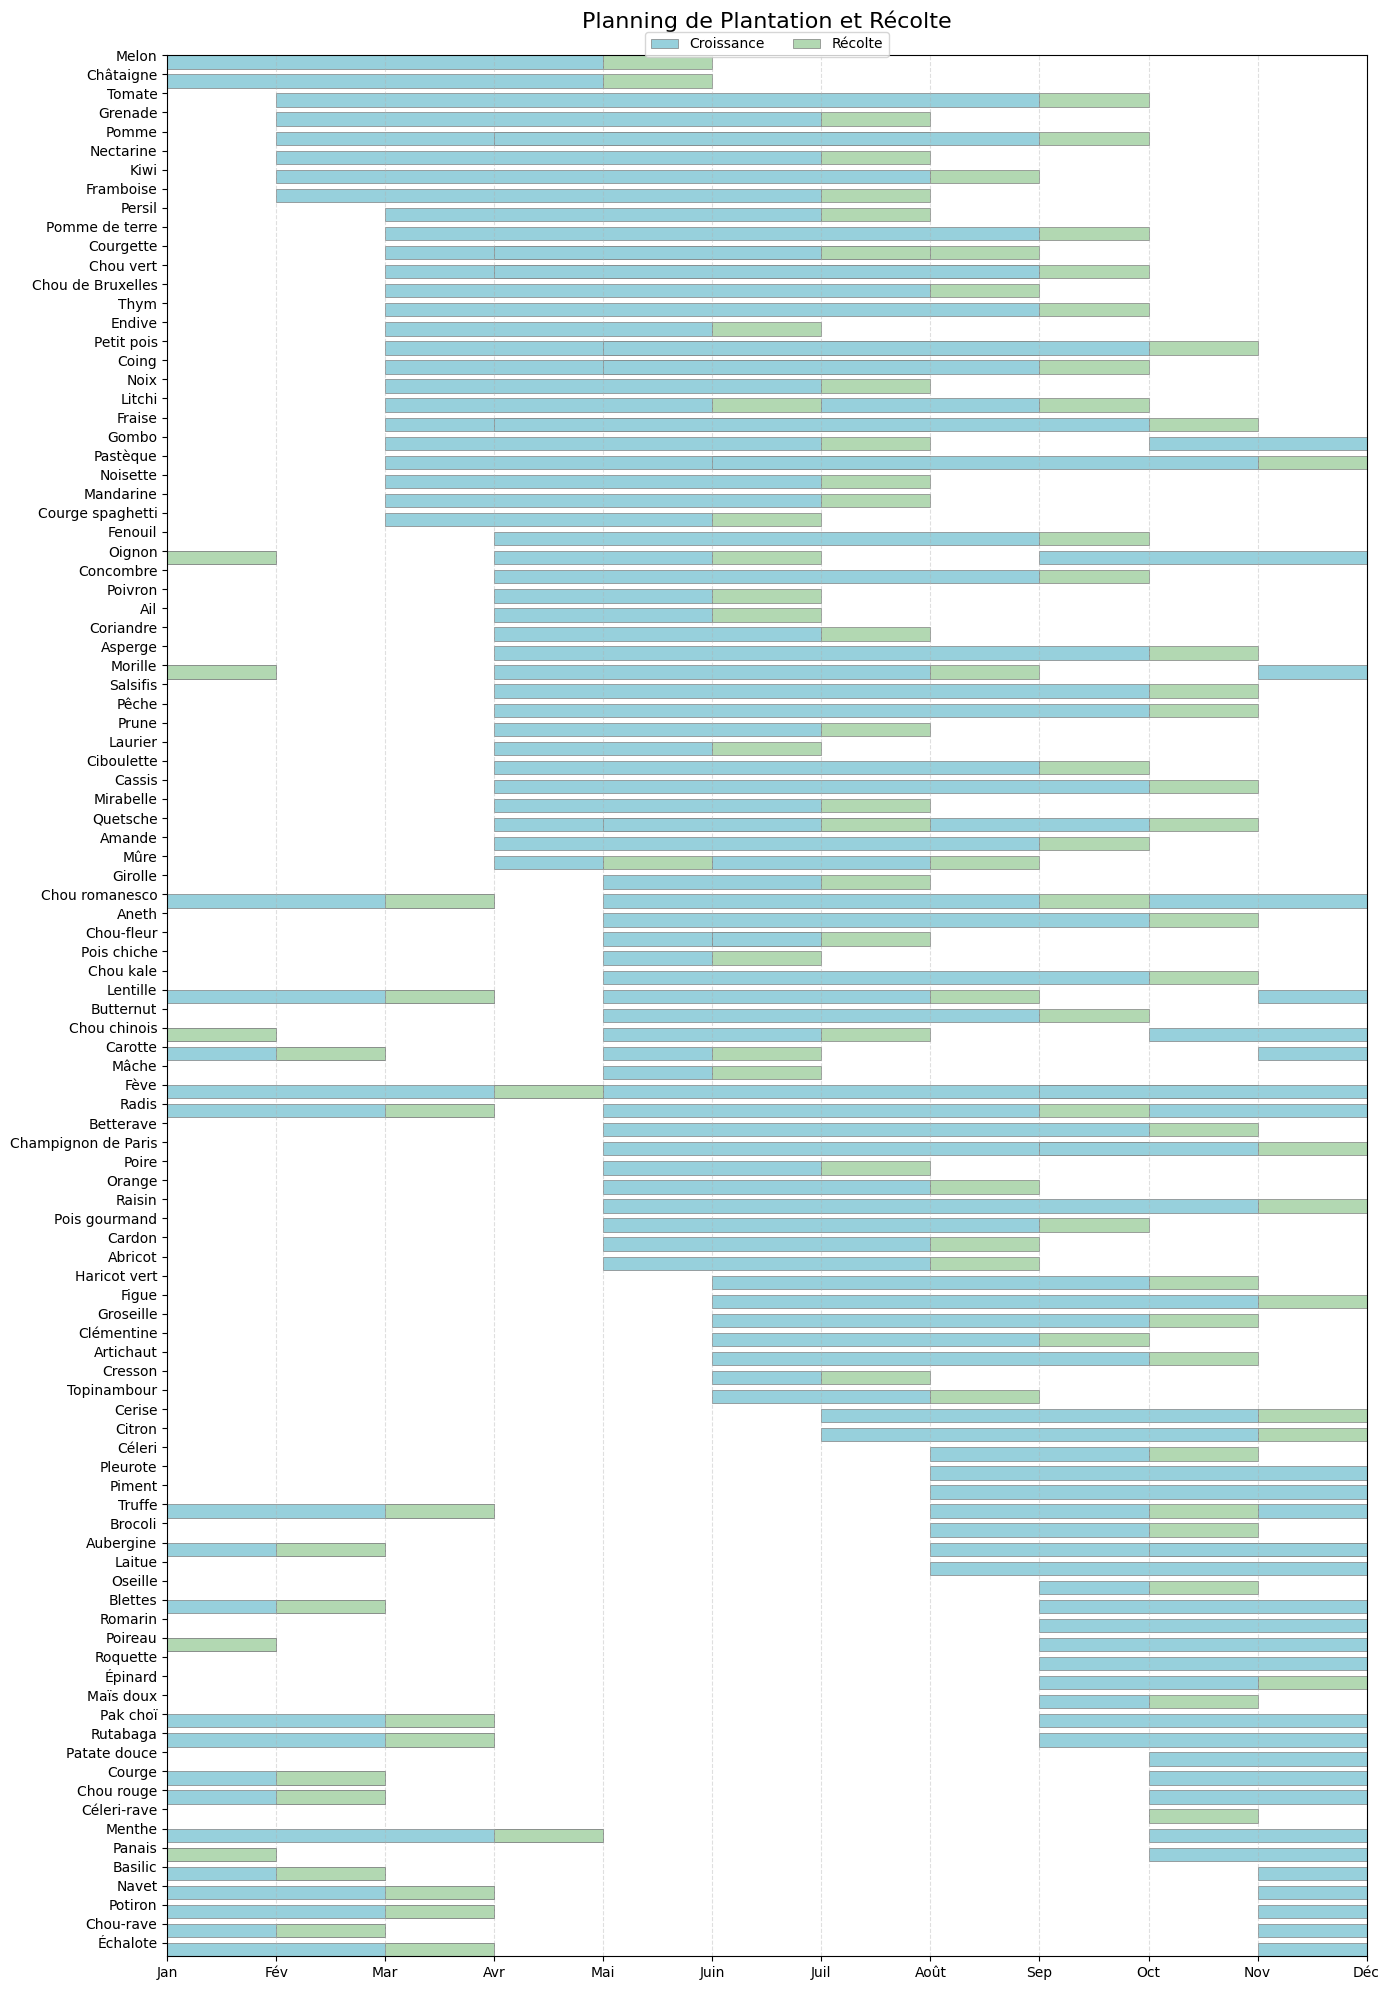

In [40]:
fig, ax = plt.subplots(figsize=(14, 20))

for i, row in df.iterrows():
    nom = row['nom_culture']
    debut = row['mois_semis']
    fin = row['mois_recolte']

    c_pousse = "#97d0dc"
    c_recolte = '#b2d8b2'

    if debut <= fin:

        ax.barh(nom, min(fin - debut, 12 - debut + 1), left=debut,
                color=c_pousse, height=0.7, edgecolor='gray', linewidth=0.5, align='edge')

        if fin <= 12:
            ax.barh(nom, 1, left=fin, color=c_recolte, height=0.7, edgecolor='gray', linewidth=0.5, align='edge')

    else:

        ax.barh(nom, 12 - debut + 1, left=debut,
                color=c_pousse, height=0.7, edgecolor='gray', linewidth=0.5, align='edge')

        if fin >= 1:
            ax.barh(nom, min(fin, 12), left=1,
                    color=c_pousse, height=0.7, edgecolor='gray', linewidth=0.5, align='edge')

        if fin <= 12:
            ax.barh(nom, 1, left=fin, color=c_recolte, height=0.7, edgecolor='gray', linewidth=0.5, align='edge')


ax.set_title("Planning de Plantation et Récolte", fontsize=16, pad=20)
ax.invert_yaxis()
ax.set_xlim(1, 12)
ax.margins(y=0)

mois_noms = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin',
             'Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc']
ax.set_xticks(range(1, 13))
ax.set_xticklabels(mois_noms)

ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.legend(['Croissance', 'Récolte'],
          loc='upper center',
          bbox_to_anchor=(0.5, 1.016),
          ncol=2)

plt.tight_layout()
plt.show()

On observe que certaines cultures ont une fenêtre de croissance longue (ex. tomate ou nectarine jusqu’en septembre-octobre), tandis que d’autres sont concentrées sur quelques mois (ex. épinard ou navet en automne-hiver). Cette hétérogénéité confirme qu’un calendrier unique serait inadapté.

Utilité pour la suite : Cette visualisation constitue la base fonctionnelle de l’application web, permettant de générer un planning dynamique selon la culture sélectionnée et les conditions climatiques locales.

Hypothèse : La plantation devient possible lorsque la température minimale du sol dépasse le seuil de germination fixé à 10°C.

/tmp/ipykernel_643/1487719970.py:3: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



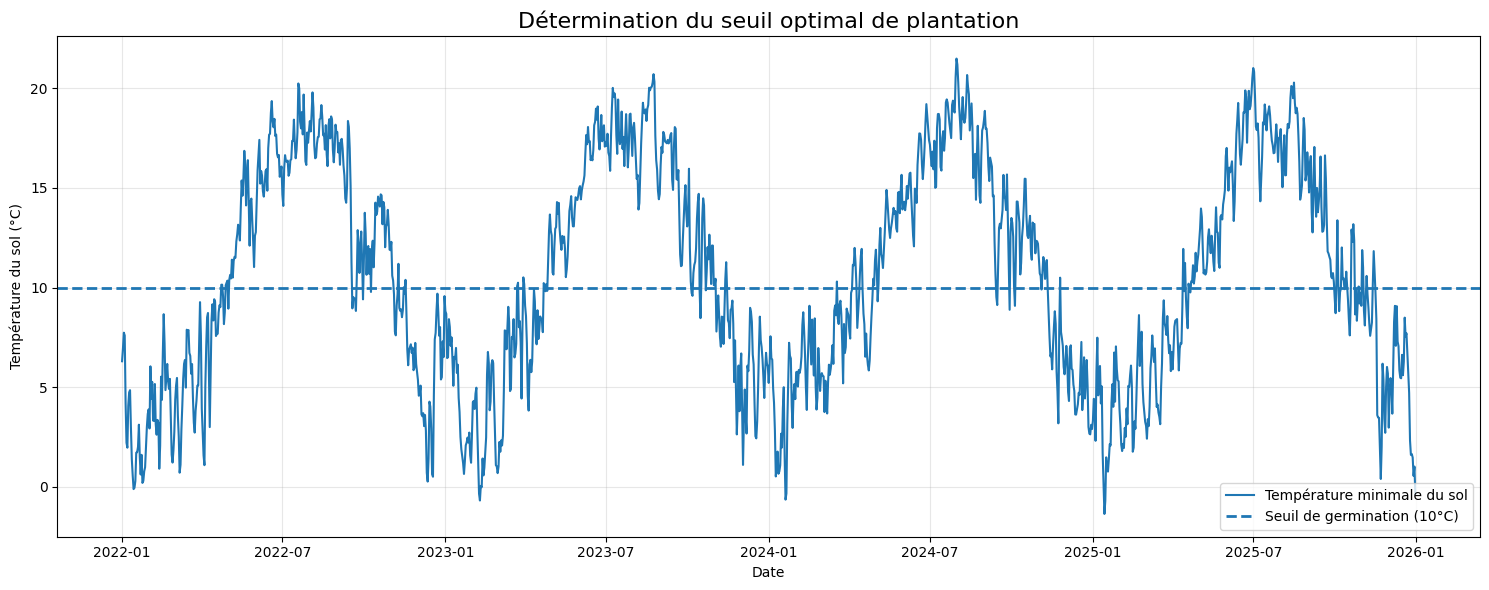

In [42]:
# Récupération données température sol

df = pd.read_sql("""

SELECT
date,
temperature_min_sol_12h

FROM releve_meteo

ORDER BY date

""", bdd)

# Préparation données

df["date"] = pd.to_datetime(df["date"])

# Conversion Kelvin → Celsius
df["temperature_min_sol_12h"] = df["temperature_min_sol_12h"] - 273.15

# Moyenne journalière (car données toutes les 3h)
df_jour = df.groupby("date")["temperature_min_sol_12h"].mean().reset_index()

# Définition du seuil de germination

seuil = 10  # seuil en °C (modifiable selon culture)

# Visualisation

plt.figure(figsize=(15,6))

# Courbe température du sol
plt.plot(
    df_jour["date"],
    df_jour["temperature_min_sol_12h"],
    label="Température minimale du sol",
)

# Ligne seuil
plt.axhline(
    y=seuil,
    linestyle="--",
    linewidth=2,
    label="Seuil de germination (10°C)"
)

plt.title(
    "Détermination du seuil optimal de plantation",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Température du sol (°C)")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

On observe que ce seuil est franchi chaque année autour du printemps et reste majoritairement au-dessus jusqu’à la fin de l’été, tandis qu’il est largement en dessous en hiver. Cela permet d’identifier précisément la fenêtre annuelle de semis sécurisée.

Utilité pour la suite : Cette règle constitue un critère décisionnel automatique exploitable dans le modèle pour proposer des dates de plantation adaptées à chaque année et localisation.

# Synthèse

L’analyse exploratoire a permis de mettre en évidence une structuration claire des données agricoles autour de trois dimensions fondamentales : le climat, le sol et les exigences thermiques des cultures.

Les analyses temporelles et saisonnières montrent un cycle climatique stable, caractérisé par des étés chauds et secs et des hivers plus froids et humides. Les corrélations confirment la cohérence des variables météorologiques, notamment la forte relation entre température de l’air et température du sol, ainsi que le lien entre précipitations et humidité.

Le clustering climatique révèle des régimes distincts (froid, tempéré, chaud), tandis que le clustering des sols met en évidence des profils pédologiques différenciés (sableux, intermédiaires, argileux). Leur combinaison via l’analyse en composantes principales (PCA) permet d’identifier des environnements agricoles cohérents, caractérisés par des combinaisons spécifiques sol-climat.

Par ailleurs, la comparaison entre températures moyennes observées et températures idéales de croissance des cultures met en évidence des écarts significatifs pour certaines espèces, justifiant une adaptation régionale et saisonnière des recommandations.


Cette phase exploratoire constitue une étape fondamentale pour la suite du projet en machine learning. Elle permet d’identifier les variables explicatives pertinentes, de limiter la redondance entre variables corrélées et de structurer les données en profils exploitables par des algorithmes de classification ou de recommandation. Ainsi, l’analyse réalisée pose les bases méthodologiques d’un système d’aide à la décision capable d’associer automatiquement un environnement donné (sol + climat) aux cultures les plus adaptées.